# Midterm Exam (part 3) - Computational Physics I

### Deadline: Monday 7 April 2024 (by 19h00)
### Name: Silva Alejandro

## Part 3. (12 points) Data analysis and visualisation (Rayleigh-Taylor instability)

The **Rayleigh-Taylor instability** occurs at the interface between two fluids of different densities when the lighter fluid is pushing the heavier fluid. Examples include the behavior of water suspended above oil in the gravity of Earth, mushroom clouds like those from volcanic eruptions and atmospheric nuclear explosions, supernova explosions in which expanding core gas is accelerated into denser shell gas.

In this problem, you will analyse a simulation of the Rayleigh-Taylor instability arising at the interface between 2 gases (one heavy and one light) in 2D. The initial condition consists of an interface separating two gases with different densities in hydrostatic balance:

$$
\rho(y) = \begin{cases}
1 & \text{for } y \le 0 \\
\eta & \text{for } y > 0
\end{cases}
\,,\qquad
p = p_0 + \rho\,y\,g
$$

where $\eta$ is the density of the gas on top in code units, $g$ is the (constant) gravity pointing in the negative $y$ direction. The system is destabilized by perturbing the vertical velocity in proximity of the interface using a single mode perturbation. The computational domain has **periodic boundary conditions** along the $X-$axis and and **reflective boundary conditions** along the $Y-$axis. The dimensions of the Cartesian domain are: $x\in[-0.5,0.5]$ and $y\in[-1.0,1.0]$ in code units.


The mono-atomic gas has an adiabatic index $\gamma=\frac{5}{3}$, and the numerical simulation produces $101$ VTK files stored in the **Rayleigh-Taylor** zipped folder: 

https://www.dropbox.com/scl/fi/j43rixdhy9upkgt76t2kl/Rayleigh_Taylor.zip?rlkey=jgliqdj4p94igr2xxna05iyax&st=h59onv8c&dl=0

which also contains the following descriptor files:

- a **units.out** file that contains the CGS normalisation values.
- a **vtk.out** file whose second column contains the times in code units.
- a **grid.out** file that contains information on the grid structure.

You can use VisIt to inspect the data. The written fields are: 

- density (rho)
- thermal pressure (prs)
- velocity_x (vx1)
- velocity_y (vx2)
- tracer (tr1), which is a pigment tracing the heavier gas on top.

**References:**

https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Taylor_instability

https://iopscience.iop.org/article/10.1086/523099

### Requirements and paths
The following libraries and specification of paths are required to run this notebook.

In [1]:
#Import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import pandas as pd
import scipy.optimize as opt
from skimage.transform import rescale, resize
import scipy.constants as cte
import glob 
from IPython import display
from PIL import Image 
import os

In [2]:
## Input
input_path_data = "/home/prostofsound/jnotebooks/computational-physics-1/exams/data/Rayleigh_Taylor_data/" #change to your desired directory

In [3]:
## Create an output folder
if os.path.isdir("/home/prostofsound/jnotebooks/computational-physics-1/exams/output_data"): #change to your desired directory
    print("Directory already exists.")
else:
    print("Directory has been created.")
    os.mkdir("/home/prostofsound/jnotebooks/computational-physics-1/exams/output_data")

Directory already exists.


In [4]:
## Output
output_path_data = "/home/prostofsound/jnotebooks/computational-physics-1/exams/output_data"

## Part A: I/O and visualisation

### (a) Create a python function that reads the **units.out** file, stores the normalisation values for length, velocity, and density, calculates the normalisation values for thermal pressure and time, and returns them all into tuple objects.

Let's first inspect the file $\textbf{units.out}$.

In [5]:
%%bash
cd data/Rayleigh_Taylor_data/
cat units.out

variable,normalisation,units
rho_0,1.673e-24,g/cm^3
v_0,1.000e+05,cm/s
L_0,1.496e+13,cm


Since it is a $\textbf{.csv}$ file, we can use pandas to read it and be able to work with it.

In [6]:
def read_units_RT(input_path_data):
    """
    This function reads the normalisation units as arrays and calculates the derived units for thermal pressure and time.
    It returns them along with the values for length, velocity and density inside a tuple. 
    Note that we're working in the CGS system of units.
    Inputs: input_path_data (str, path to file)
    Output: units (array, tuple with the normalisation units)
    Author: AlejoS
    Date: 04/04/2025
    """
    #Read the file
    sim_units = pd.read_csv(input_path_data + "units.out")

    #Retrieve the normalisation units and convert them to arrays, just to handle them easier
    L_0 = np.array(sim_units.loc[sim_units["variable"] == "L_0"]["normalisation"])
    v_0 = np.array(sim_units.loc[sim_units["variable"] == "v_0"]["normalisation"])
    rho_0 = np.array(sim_units.loc[sim_units["variable"] == "rho_0"]["normalisation"])

    #Calulate the derived normalisation units
    p_0 = rho_0*v_0**2
    t_0 = L_0/v_0

    #Store units inside a tuple
    units = (L_0, v_0, rho_0, p_0, t_0)

    return units

### (b) Create a python function that reads the **vtk.out** file, reads the second column, and returns the times in CGS units using $t_0$ from point (a).

Let's first inspect the file $\textbf{vtk.out}$.

In [7]:
%%bash
cd data/Rayleigh_Taylor_data/
head -2 vtk.out

0 0.000000e+00 1.000000e-03 0 single_file little rho vx1 vx2 prs tr1 
1 1.892102e-01 2.893551e-03 70 single_file little rho vx1 vx2 prs tr1 


Since the values are separated by spaces (we're not sure how many), we have to specify this when opening the file. Also, there is no header.

In [8]:
def read_time_RT(input_path_data, units):
    """
    This function reads the time snapshots of the simulation and converts it to CGS units using the derived normalistion unit for time.
    It returns the times stored in an array.
    Inputs: inputh_path_data (str, path to file), units (tuple, it contains the normalisation units)
    Output: t_cgs (array)
    Author: AlejoS
    Date: 04/04/2025
    """
    #Read file
    sim_time = pd.read_csv(input_path_data + "vtk.out", sep = "\s+", header = None)

    #Retrieve the second column, where the time data is stored, and convert to an array object
    times = np.array(sim_time.iloc[:,1])

    #Convert to GCS units
    times_cgs = times*units[-1]

    return times_cgs

### (c) Create a python function that reads a VTK data file, normalises the data fields to CGS units using the values from points (a) and (b), and returns them jointly with the mesh and time information as tuple objects. Note that the tracer is dimensionless, so it does not require normalisation.

We have to use pyvista to read the VTK file.

In [9]:
def read_sim_RT(filename, units, t_cgs):
    """
    This function reads a VTK data file of a simulation of the Rayleigh-Taylor instability arising at the interface
    between 2 gases (one heavy and one light) in 2D. 
    It normalises the data fields to CGS units and returns them along with the mesh and time information as arrays inside a tuple.
    Inputs: filename (str, path to file), units (tuple, it contains the normalisation units), t_cgs (array, the cgs time)
    Output: data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units)
    Author: AlejoS
    Date: 04/04/2025
    """
    #Get the data into a mesh
    mesh = pv.read(filename)

    #Get the flattened arrays, we have 5
    rho = pv.get_array(mesh, "rho", preference = 'cell')
    vx1 = pv.get_array(mesh, "vx1", preference = 'cell')
    vx2 = pv.get_array(mesh, "vx2", preference = 'cell')
    prs = pv.get_array(mesh, "prs", preference = 'cell')
    tr1 = pv.get_array(mesh, "tr1", preference = 'cell')

    #Normalise to CGS units
    rho_cgs = rho*units[2]
    vx1_cgs = vx1*units[1]
    vx2_cgs = vx2*units[1]
    prs_cgs = prs*units[3]
    #tr1 does not require normalisation

    #Reshape them into 2D arrays
    rho_cgs2d = rho_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1) #substract 1 to get the proper cell dimension
    vx1_cgs2d = vx1_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1)
    vx2_cgs2d = vx2_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1)
    prs_cgs2d = prs_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1)
    tr1_2d = tr1.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1)
    
    #Rescale, to save memory when looping over all the data files
    rho_cgs2d_rsc = rescale(rho_cgs2d, scale = 0.5, preserve_range = True, anti_aliasing = True)
    vx1_cgs2d_rsc = rescale(vx1_cgs2d, scale = 0.5, preserve_range = True, anti_aliasing = True)
    vx2_cgs2d_rsc = rescale(vx2_cgs2d, scale = 0.5, preserve_range = True, anti_aliasing = True)
    prs_cgs2d_rsc = rescale(prs_cgs2d, scale = 0.5, preserve_range = True, anti_aliasing = True)
    tr1_2d_rsc = rescale(tr1_2d, scale = 0.5, preserve_range = True, anti_aliasing = True)
    
    #Store arrays in a tuple
    data_tuple = (mesh, t_cgs, rho_cgs2d_rsc, vx1_cgs2d_rsc, vx2_cgs2d_rsc, prs_cgs2d_rsc, tr1_2d_rsc)

    return data_tuple

### (dx2) Call all the above functions for VTK file **# 75** of each simulation, and make the following maps using the correct mesh coordinates, dimensions and time, all in in CGS units:

- A figure showing the gas density, $\rho$.

- A figure showing the gas sound speed, $c_s=\sqrt{\gamma\frac{p}{\rho}}$.

- A figure showing showing the kinetic energy density, $E_k = \frac{1}{2}\rho\,v^2$ with $v=\sqrt{v_x^2+v_y^2}$.

- A figure showing the tracer, $h_{gas}\equiv \rm tr1$, of the heavier gas.

**Notes:** Choose different perceptually-uniform colour schemes for each of the above quantities, and fix the colour bar limits. Add the correct time stamp in CGS units to each map. Since these are high-resolution models, one way to improve the visualisation of 2D vector fields is to interpolate them into a coarser grid.

In [10]:
filename = input_path_data + "data.0075.vtk"

In [11]:
#Call our functions
data_units = read_units_RT(input_path_data)
data_times_cgs = read_time_RT(input_path_data, data_units)
data_info = read_sim_RT(filename, data_units, data_times_cgs)

In [12]:
# Generate the grid vectors in physical units, using the mesh information
x = np.linspace(data_info[0].bounds[0], data_info[0].bounds[1],\
                (data_info[0].dimensions[0] - 1)//2)*data_units[0] #also multiply by rescaling factor
y = np.linspace(data_info[0].bounds[2], data_info[0].bounds[3],\
                (data_info[0].dimensions[1] - 1)//2)*data_units[0]

#Generate the grid
x_2D, y_2D = np.meshgrid(x,y)

#Safe check
print(x_2D.shape, y_2D.shape)

(256, 128) (256, 128)


#### Plotting $\rho$:

In [13]:
#Check the min and max values
print(np.min(data_info[2]), np.max(data_info[2]))

#A linear scale is fine.

1.558847583383345e-24 3.668712286453493e-24


In [14]:
print(data_info[2].shape)

(256, 128)


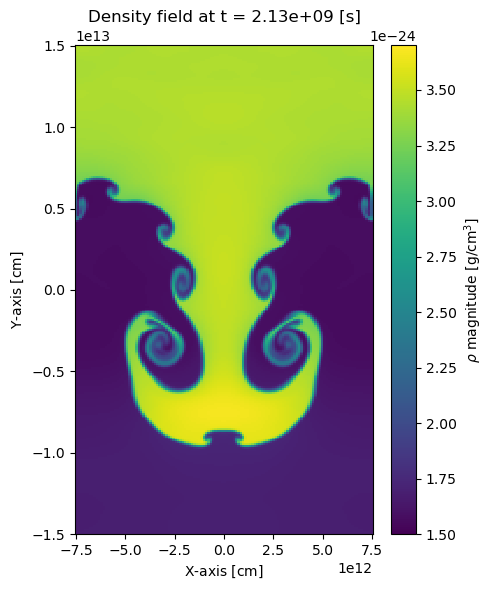

In [15]:
# Plotting the density
plt.figure(figsize=(5,6))

RT_dens = plt.pcolor(x_2D, y_2D, data_info[2], cmap ="viridis", vmin = 1.5e-24, vmax = 3.7e-24)

cbar = plt.colorbar(RT_dens)
cbar.set_label(r"$\rho$ magnitude [$\text{g/cm}^3$]") 

# Add title with time
t_stamp = data_info[1][75]
plt.title(f"Density field at t = {t_stamp:.2e} [s]")

#Axes names
plt.xlabel(r"$\text{X-axis [cm]}$")
plt.ylabel(r"$\text{Y-axis [cm]}$")

#Show
plt.tight_layout()
plt.show()

It's very important to compare our obtained plots with the actual ones, using Visit for example.

#### Plotting $c_s$

In [16]:
#Define the adiabatic index
adb_idx = 5/3

#Compute the gas sound speed
c_gas = np.sqrt(adb_idx*data_info[-2]/data_info[2])

In [17]:
#Check the min and max values
print(np.min(c_gas), np.max(c_gas))

#A linear scale is fine.

58229.86402853479 108409.48711093704


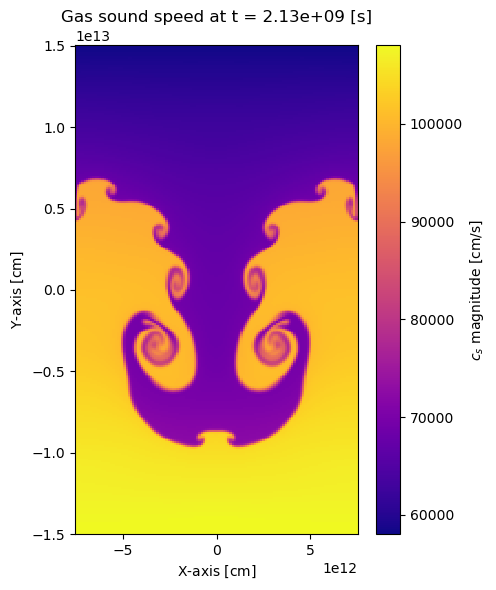

In [18]:
# Plotting the gas sound speed
plt.figure(figsize=(5,6))

RT_gas = plt.pcolor(x_2D, y_2D, c_gas, cmap ="plasma", vmin = 58e3, vmax = 108e3)

cbar = plt.colorbar(RT_gas)
cbar.set_label(r"$c_s$ magnitude [$\text{cm/s}$]")

# Add title with time
t_stamp = data_info[1][75]
plt.title(f"Gas sound speed at t = {t_stamp:.2e} [s]")

#Axes names
plt.xlabel(r"$\text{X-axis [cm]}$")
plt.ylabel(r"$\text{Y-axis [cm]}$")

#Show
plt.tight_layout()
plt.show()

#### Plotting $E_k$:

In [19]:
#Compute the kinetic energy density
kine_den = 0.5*data_info[2]*(data_info[3]**2 + data_info[4]**2)

In [20]:
#Check the min and max values
print(np.min(kine_den), np.max(kine_den))

#A log scale should be used.

1.5934081702055917e-22 1.0979378544030581e-15


In [21]:
#Check the min and max values
print(np.min(np.log10(kine_den)), np.max(np.log10(kine_den)))

-21.79767296031837 -14.959422241173398


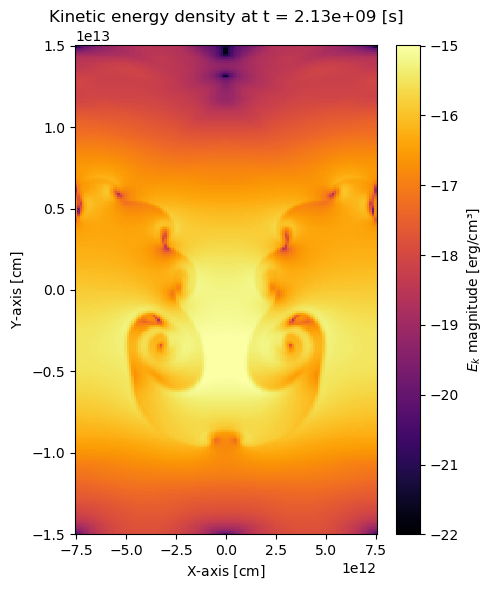

In [22]:
# Plotting the kinetic energy density
plt.figure(figsize=(5,6))

RT_kden = plt.pcolor(x_2D, y_2D, np.log10(kine_den), cmap ="inferno", vmin = -22, vmax = -15)

cbar = plt.colorbar(RT_kden)
cbar.set_label(r"$E_k$ magnitude [$\text{erg/cm³}$]")

# Add title with time
t_stamp = data_info[1][75]
plt.title(f"Kinetic energy density at t = {t_stamp:.2e} [s]")

#Axes names
plt.xlabel(r"$\text{X-axis [cm]}$")
plt.ylabel(r"$\text{Y-axis [cm]}$")

#Show
plt.tight_layout()
plt.show()

#### Plotting $h_{gas}$:

In [23]:
#Check the min and max values
print(np.min(data_info[-1]), np.max(data_info[-1]))

#A linear scale is fine.

-0.00097357424 1.0010003


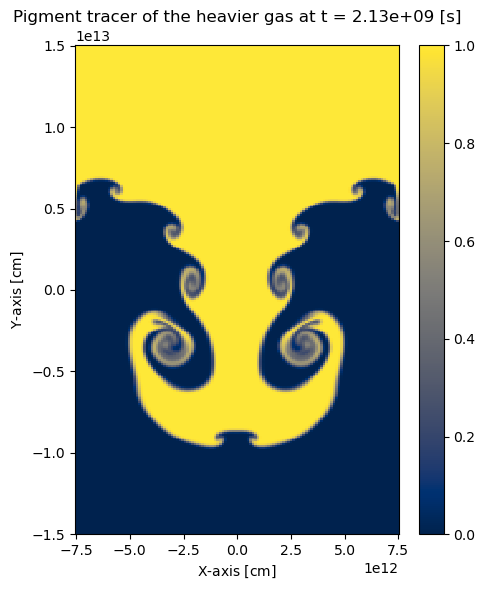

In [24]:
# Plotting the pigment tracer of the heavier gas
plt.figure(figsize=(5,6))

RT_tr = plt.pcolor(x_2D, y_2D, data_info[-1], cmap ="cividis", vmin = 0, vmax = 1.)

plt.colorbar(RT_tr)

# Add title with time
t_stamp = data_info[1][75]
plt.title(f"Pigment tracer of the heavier gas at t = {t_stamp:.2e} [s]")

#Axes names
plt.xlabel(r"$\text{X-axis [cm]}$")
plt.ylabel(r"$\text{Y-axis [cm]}$")

#Show
plt.tight_layout()
plt.show()

## Part B: Analysis of the density field

### (e) Create a set of Python functions that loop over all the VTK simulation files and returns maps of the density field $\rho$, the kinetic energy density $E_k$, and also histograms of the density field in CGS units for all times, into a folder called **"output_data"**.

In [25]:
#Plotting function for the density field

def plt_rho(index, data_info, boolean, output_path_data):
    """
    This function plots the density field of the (index)th VTK data file. It also saves the image.
    Inputs: index (number of file, integer), data_info(tuple, it contains the 2D arrays (in CGS) of the simulation)\
    boolean (boolean, to show if necessary), output_path_data (str, path to save the plot)
    Output: image (array)
    Author: AlejoS
    Date: 04/04/2025
    """
    #Figure environment
    plt.figure(figsize=(5,6))
    
    RT_dens = plt.pcolor(x_2D, y_2D, data_info[2], cmap ="viridis", vmin = 1.5e-24, vmax = 3.7e-24)
    
    cbar = plt.colorbar(RT_dens)
    cbar.set_label(r"$\rho$ magnitude [$\text{g/cm}^3$]") 
    
    # Add title with time
    t_stamp = data_info[1][index]
    plt.title(f"Density field at t = {t_stamp:.2e} [s]")

    #Axes names
    plt.xlabel(r"$\text{X-axis [cm]}$")
    plt.ylabel(r"$\text{Y-axis [cm]}$")
    plt.tight_layout()
    
    #Show
    if boolean:
        plt.show()
    #Save
    plt.savefig(f"{output_path_data}/densityf_at_{index:03d}.png")
    plt.close() #to avoid possible memory issues

In [26]:
#Plotting function for Ek

def plt_kined(index, data_info, output_path_data):
    """
    This function plots the kinetic energy density field of the (index)th VTK data file. It also saves the image.
    Inputs: index (number of file, integer), data_info(tuple, it contains the 2D arrays (in CGS) of the simulation),\
    output_path_data (str, path to save the plot).
    Output: image (array).
    Author: AlejoS
    Date: 04/04/2025
    """
    #Compute the kinetic energy density
    kine_den = 0.5*data_info[2]*(data_info[3]**2 + data_info[4]**2)

    # Plotting the kinetic energy density
    #Figure environment
    plt.figure(figsize=(5,6))
    
    RT_kden = plt.pcolor(x_2D, y_2D, np.log10(kine_den), cmap ="magma", vmin = -22, vmax = -15)
    
    cbar = plt.colorbar(RT_kden)
    cbar.set_label(r"$E_k$ magnitude [$\text{erg/cm³}$]")
    
    # Add title with time
    t_stamp = data_info[1][index]
    plt.title(f"Kinetic energy density at t = {t_stamp:.2e} [s]")

    #Axes names
    plt.xlabel(r"$\text{X-axis [cm]}$")
    plt.ylabel(r"$\text{Y-axis [cm]}$")
    
    #Save
    plt.tight_layout()
    plt.savefig(f"{output_path_data}/kin_dens_at_{index:03d}.png")
    plt.close() #to avoid possible memory issues

In [27]:
#Plot the denisity field histogram and return the midpoints and count vectors
def plt_denhist(index, data_info, boolean, output_path_data):
    """
    This function plots the density field histogram as a scatter plot. It first calculates the bins and values of the histogram,
    then gets the midpoints and shifts the array to finally make the plot.
    Inputs: index (number of file, integer), boolean (boolean, to show the image if necessary),\
    data_info(tuple, it contains the 2D arrays (in CGS) of the simulation),\
    output_path_data (str, path to save the plot).
    Output: image (array), x1 (array, midpoints of the bin edges, scaled), n1 (array, normalized counts in each bin, scaled)
    Author: AlejoS
    Date: 05/04/2025
    """
    #Flatten the array to 1D
    rhocgs_1D = np.reshape(data_info[2], (data_info[2].size, 1))
    
    #Get the bins and values of the histogram
    n, bins = np.histogram(rhocgs_1D, 100, density = True)

    #Get midpoints
    # Shift arrays:
    x0 = 0.5 * ( bins[1:] + bins[:-1] ) #when making tests, it was seen that the axes need a renormalisation

    #Renormalise axes
    n1 = n/1.e24
    
    x1 = x0/1.e-24

    #Plotting
    #Figure environment
    plt.figure(figsize=(5,4))

    # New histogram plot:
    plt.scatter(x1, n1, marker = "*", color = "red", s = 25)

    # Add title with time
    t_stamp = data_info[1][index]
    plt.title(f"Histogram of density field at t = {t_stamp:.2e} [s]")
    
    #Axes names
    plt.xlabel(r"$\rho$ [g/cm$^3$]")
    plt.ylabel(r"N pixels")
    
    #Show/Save
    plt.tight_layout()
    #Save
    plt.savefig(f"{output_path_data}/dens_hist_at_{index:03d}.png")
    #Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

    return x1, n1

In [28]:
# #Read each data file and get the data info tuple of each one

# # 1. Get the normalisation units and the time array in cgs units
# data_units = read_units_RT(input_path_data)
# t_cgs = read_time_RT(input_path_data, data_units)

# # 2. Iterate over all the simulation files
# for j in range(0, 101):
#     filename = input_path_data + "data.0{:03d}.vtk".format(j)
#     #print(filename)
    
#     # 3. Open the file j and retrieve the mesh and all the arrays
#     data_info = read_sim_RT(filename, data_units, t_cgs)
#     #Note that it's not necessary to create the meshgrid each time. Moreover, we already have it.
    
#     # 4. Call the plotting functions
#     plt_rho(j, data_info, False, output_path_data)
#     plt_kined(j, data_info, output_path_data)
#     x1, n1 = plt_denhist(j, data_info, False, output_path_data)

The cell above was commented to save computational time when runnig all the notebook. Please, uncomment it when necessary.

### (f) Briefly describe: what happens with the density field as time progresses? Does the density field follow any statistical distribution at late times?

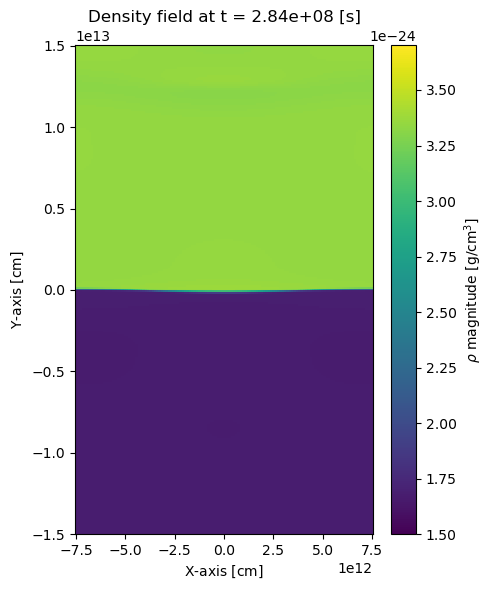

In [29]:
#Let's check the density field at the beginning
filename = input_path_data + "data.0010.vtk"
#Call our functions
data_units = read_units_RT(input_path_data)
data_times_cgs = read_time_RT(input_path_data, data_units)
data_info = read_sim_RT(filename, data_units, data_times_cgs)
#Plot
plt_rho(10, data_info, True, output_path_data)

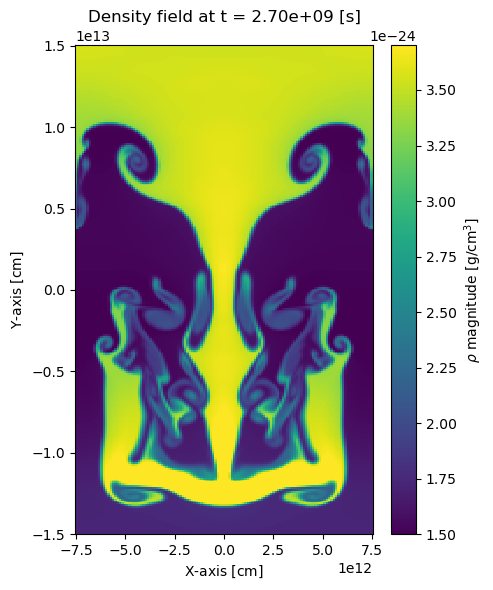

In [30]:
#Let's check the density field close to the end of the simulation
filename = input_path_data + "data.0095.vtk"
#Call our functions
data_info = read_sim_RT(filename, data_units, data_times_cgs)
#Plot
plt_rho(95, data_info, True, output_path_data)

In the beginning there is a clear horizontal distinction between the two fluids regions. Then, as time progresses we first see the formation of Kelvin-Helmholtz instabilities and, close to the end, we see the formation of the characteristic "mushroom" of the Rayleigh-Taylor instability at the interface. The lighter fluid pushes upward the heavier fluid and the heavier fluid falls down.

This is all consequence of the relation between the density gradient(which points upwards) and the gravitational acceleration, which points in the opposite direction.

We can carry out a regression of the density field histogram of $\text{data file 080}$.

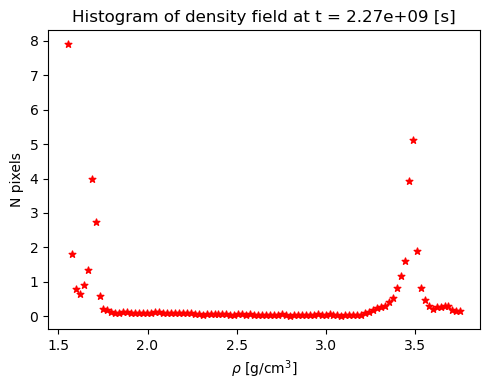

(100,) (100,)


In [31]:
#Define path data
filename = input_path_data + "data.0080.vtk"

#Call the function to read the simulation
data_info = read_sim_RT(filename, data_units, data_times_cgs)

#Call the function to plot, show the density field histogram and return the values vector
x1, n1 = plt_denhist(80, data_info, True, output_path_data)

#Safe check
print(x1.shape, n1.shape)

In [32]:
# Define the model for the fit
def dbl_log_normal(x, mu1, s1, a1):
    """
    Function to define a log-normal distro.
    nputs: x (array, data), mu1 (float, centers), s1 (float, sigma), a1 (float, height).
    Output: y_model (array, log-normal model)
    Author: AlejoS
    Date: 06/05/2025
    """
    y1 = a1 * (np.exp(-(np.log(x) - mu1)**2 / (2 * s1**2)) / (x * s1 * np.sqrt(2 * np.pi)))

    return y1

In [33]:
# Fitting:
# Call the minimisation routine
coef_df, cov_df = opt.curve_fit(dbl_log_normal, x1, n1, [1.31, 0.02, 5])

#Safe check
print(cov_df)

[[2.23144684e-06 1.68909615e-08 7.08782179e-07]
 [1.68909615e-08 2.23367635e-06 4.75212821e-05]
 [7.08782179e-07 4.75212821e-05 3.03138542e-03]]


In [34]:
# Evaluate the fit in the model
df_fit = dbl_log_normal(x1, *coef_df)

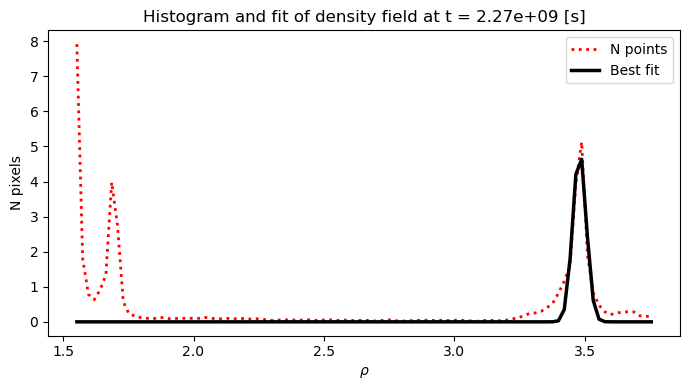

In [35]:
# Plotting to compare
#Figure environment
plt.figure(figsize=(7,4))

# New histogram plot:
plt.plot(x1, n1, linestyle = ":", color = "red", lw = 2, label = "N points")
plt.plot(x1, df_fit, linestyle = "-", color = "black", lw = 2.5, label = "Best fit" )

# Add title with time
t_stamp = data_info[1][80]
plt.title(f"Histogram and fit of density field at t = {t_stamp:.2e} [s]")
    
#Axes names
plt.xlabel(r"$\rho$")
plt.ylabel(r"N pixels")
plt.legend()
    
#Show
plt.tight_layout()
plt.show()
plt.close()

A sum of log normal distributions is somehow not enough to match the data points, so I tried with just one. It worked but just to fit one of the peaks. I'd say that we have a mixture of a binomial distribution and a log normal distribution for the density field at late times.

We have to peaks in the histogram because of the difference in density of the fluids.

## Part C: Time evolution and derivatives

### (gx2) Create a set of Python functions that loops over all the VTK simulation files, computes the following quantities in CGS units for each time:

- the average gas temperature, $\overline T$, (**Hint:** the temperature in each grid cell can be calculated using the equation of state for ideal gases, i.e., $p=\frac{\rho\,k_B\,T}{\mu\,m_u}$, where $k_B$ is the Boltzmann constant, $m_u$ is the atomic mass unit, and $\mu=0.6$ is the mean particle mass in the gas.)

- the average kinetic energy density of the gas, $\overline E_k$, where $E_k = \frac{1}{2}\rho\,v^2$.

- the rate of change of average kinetic energy density, $\dot{\overline E_k}$.

- the average sound speed of the heavier gas, $\overline c_{s,h}$, where $c_{s,h}=h_{gas}\,\sqrt{\gamma\,\frac{p}{\rho}}$

and returns:

- a CSV file with 5 columns, time on the first column, and the above quantities in the next ones. The CSV file should be named **"stats.csv"** saved into the folder called **"output_data"**.

In [36]:
# Calculations function
def calculations(index, data_info):
    """
    This function computes the average gas temperature, the average kinetic energy and the average sound speed of the heavier gas;\
    for each VTK data file.
    Inputs: index (number of file, integer), data_info(tuple, it contains the 2D arrays (in CGS) of the simulation)
    Outputs: avg_T (float, average T), avg_ken_dens (float, average Ek), avg_cs(float, average c_s)
    Author: AlejoS
    Data: 05/04/2025
    """
    ## AVG Gas Temperature
    # Import constants and convert to CGS units
    # Convert atomic mass to CGS (grams)
    amass_cgs = cte.atomic_mass * 1e3  # kg to grams
    # Convert Boltzmann constant to CGS (erg/K)
    boltz_cgs = cte.Boltzmann * 1e7  # J/K to erg/K (1 J = 1e7 erg)
    
    #Get the temperature array using the EOS
    T = (data_info[-2]*0.6*amass_cgs)/(data_info[2]*boltz_cgs)

    #Compute the average gas temperature
    avg_T = np.mean(T)

    ## AVG Kinetic Energy Density
    #Compute the kinetic energy density
    kine_den = 0.5*data_info[2]*(data_info[3]**2 + data_info[4]**2)

    #Compute the average kinetic energy density
    avg_ken_dens = np.mean(kine_den)

    ## AVG Gas Sound Speed
    #Define the adiabatic index
    adb_idx = 5/3

    #Compute the gas sound speed
    c_gas = np.sqrt(adb_idx*data_info[-2]/data_info[2])

    #Compute the gas sound speed of the heavier gas
    c_hgas = data_info[-1]*c_gas

    #Compute the average gas sound speed of the heavier gas
    avg_cs = np.mean(c_hgas)

    return avg_T, avg_ken_dens, avg_cs

In [37]:
avg_T, avg_ken_dens, avg_cs = calculations(80, data_info) #data_info corresponds to data_0080, as it was called for the regression

#Safe check
print(avg_T, avg_ken_dens, avg_cs)

32.32135429021844 1.515169856330079e-16 32991.70193597109


As time progresses the average kinetic energy becomes very small, so we have to use number formatting to properly store these values.

We compute the rate of change of the average kinetic energy density after having the 1D array, with the value for each data file.

In [38]:
# Function to save arrays as a CSV file
def save_csv(calcs_tuple, output_path_data):
    """
    This function converts the given arrays inside a tuple to a Pandas DataFrame. Then, saves it as a .csv file.
    Inputs: calcs_tuple (tuple, it contains the arrays to be stored), output_path_data (output file directory)
    Output: stats.csv (CSV file)
    Author: AlejoS
    Date: 05/04/2025
    """
    # 1. Convert to a Pandas DataFrame
    calcs_df = pd.DataFrame({
        "Time [s]": calcs_tuple[0],
        "Avg. Gas T. [K]" : calcs_tuple[1],
        "Avg. K. Dens. [erg/cm³]" : calcs_tuple[2],
        "Rate of change of Avg. K. Dens. [erg/(s cm³)]" : calcs_tuple[3],
        "Avg. H. Gas sound speed [cm/s]" : calcs_tuple[4]
    })
    
    # 2. Save the data frame as .csv file:
    calcs_df.to_csv(f"{output_path_data}/stats.csv",\
                    sep=',', float_format='{:.2e}'.format) #use scientific notation

In [39]:
def calcs_RT_data(input_path_data, output_path_data):
    """
    This function loops over all the VTK data files and computes the required calculations.
    Inputs: input_path_data (str, directory to the data files), output_path_data (output file directory).
    Outputs: t_array (array, time values in cgs), avg_T_array (array, average Ts), avg_ken_dens_array (array, average Eks),\
            diff_avg_ken_dens (array, rate of change of Eks), avg_cs_array (array, average gas sound speed of the heavier gas).
    Author: AlejoS
    Data: 05/04/2025

    """
    # 1. Get the normalisation units and the time array in cgs units
    data_units = read_units_RT(input_path_data)
    t_cgs = read_time_RT(input_path_data, data_units)
    
    # 1. Define time array and empty lists
    t_array = t_cgs 
    avg_T_list = []
    avg_ken_dens_list = []
    avg_cs_list = []
    
    # 2. Loop
    for j in range(0, 101):
        filename = input_path_data + "data.0{:03d}.vtk".format(j)
        #print(filename)
        
        # 3. Open the file j and retrieve the mesh and all the arrays
        data_info = read_sim_RT(filename, data_units, t_cgs)
        #Note that it's not necessary to create the meshgrid each time. Moreover, we already have it.
        
        # 4. Compute the calculations
        avg_T, avg_ken_dens, avg_cs = calculations(j, data_info)
    
        # 5. Append to lists
        avg_T_list.append(avg_T)
        avg_ken_dens_list.append(avg_ken_dens)
        avg_cs_list.append(avg_cs)
        
    #6. Convert to arrays
    avg_T_array = np.array(avg_T_list) 
    avg_ken_dens_array = np.array(avg_ken_dens_list)
    avg_cs_array = np.array(avg_cs_list)
    
    # 7. Compute the rate of change of the average kinetic energy density
    # Define step size for integration
    d_t = t_array[1] - t_array[0]
    
    #Compute the rate of change with gradient
    diff_avg_ken_dens = np.gradient(avg_ken_dens_array, d_t, axis = 0) #we have 1D data

    # 8. Store arrays in a tuple
    calcs_tuple = (t_array, avg_T_array, avg_ken_dens_array, diff_avg_ken_dens, avg_cs_array)

    # 9. Save the calculated stats into CSV file
    save_csv(calcs_tuple, output_path_data)

    return calcs_tuple

In [40]:
calcs_tuple = calcs_RT_data(input_path_data, output_path_data)

#Safe check
print(calcs_tuple[0].shape, calcs_tuple[1].shape, calcs_tuple[2].shape, calcs_tuple[3].shape, calcs_tuple[4].shape)

(101,) (101,) (101,) (101,) (101,)


### (h) Create a Python function that reads in the CSV file created in (g) and returns (i.e. shows or saves) high-quality labeled figures of each of the above-computed quantities versus time, into the folder called **"output_data"**. 

In [41]:
def read_stats(filename):
    """
    This function reads in the created CSV file and returns the stored arrays inside a tuple.
    Inputs: filename (str, path to file)
    Outputs: stast (tuple, it contains the array)
    Author: AlejoS
    Date: 05/04/2025
    """
    #1. Read the CSV file
    stats = pd.read_csv(filename)

    #Retrieve the arrays
    t = np.array(stats["Time [s]"])
    avg_T = np.array(stats["Avg. Gas T. [K]"])
    avg_K_dens = np.array(stats["Avg. K. Dens. [erg/cm³]"])
    diff_avg_K_dens = np.array(stats["Rate of change of Avg. K. Dens. [erg/(s cm³)]"])
    avg_cs = np.array(stats["Avg. H. Gas sound speed [cm/s]"])

    #Store arrays in a tuple
    stats = (t, avg_T, avg_K_dens, diff_avg_K_dens, avg_cs)

    return stats

In [42]:
def plot_save_stats(t, quantity, title, name, boolean, output_path_data):
    """
    This function returns (i.e. shows or saves) high-quality labeled figures of each computed quantity versus time.
    Inputs: t (array, x-axis), quantity (array, quantity to be plotted (y-axis)),\
    title (str, title of the plot), name (str, name of file to be saved) boolean (boolean, to show or not the figure)),\
    output_path_data (output file directory)
    Outputs: image (array, required plot)
    Author: AlejoS
    Date: 05/04/2025
    """
    #Figure environment
    plt.figure(figsize=(7,4))

    # New histogram plot:
    plt.plot(t, quantity, color = "blue", lw = 2.5)

    # Add title
    plt.title(f"{title} vs. Time")
    
    #Axes names
    plt.xlabel(r"$\text{Time [s]}$")
    plt.ylabel(f"{title}")
    plt.grid(True)
    
    #Show/Save
    plt.tight_layout()
    #Save
    plt.savefig(f"{output_path_data}/{name}_vs_t.png")
    #Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

## Part D: Animations and steady state

### (i) Briefly describe: What happens to the average kinetic energy, its derivative, and the average sound speed of the heavier gas as time progresses? Does the flow reach steady state? 

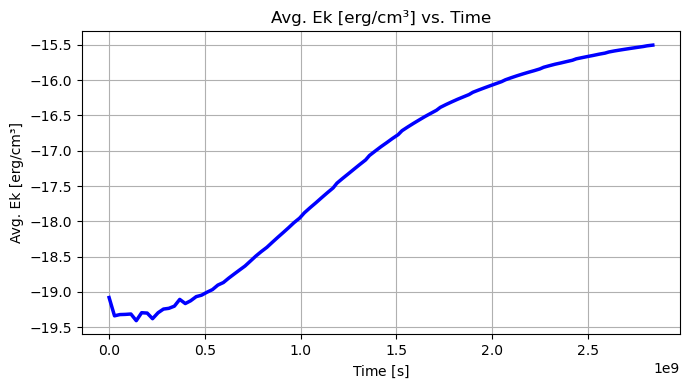

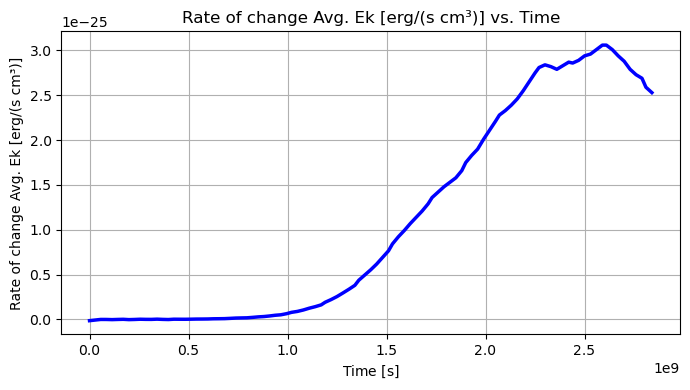

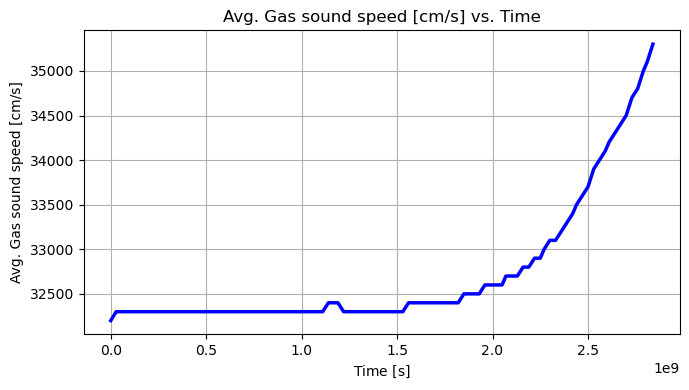

In [43]:
#Let's check the plots
#Path to file
filename1 = output_path_data + "/stats.csv"

#Call our functions
stats = read_stats(filename1)

#Plotting
plot_save_stats(stats[0], stats[1], r"Avg. Temperature [K]", "avg_T_vs_t", False, output_path_data)
plot_save_stats(stats[0], np.log10(stats[2]), r"Avg. Ek [erg/cm³]", "avg_Ek_vs_t", True,\
                output_path_data) #the orders of magnitude difference was high
plot_save_stats(stats[0], stats[3], r"Rate of change Avg. Ek [erg/(s cm³)]", "rt_avg_Ek_vs_t", True,\
                output_path_data) #the orders of magnitude difference was high
plot_save_stats(stats[0], stats[4], r"Avg. Gas sound speed [cm/s]", "avg_cs_vs_t", True,\
               output_path_data)

It's clear from the plots of the average kinetic energy and average gas sound speed, that around $t = 2.5 \times 10^9 $ s the flow starts approaching a steady state.

Regarding the decreasing rate of change of the average kinetic energy density at the end, the system is dissipating energy and thus settling into a statistically steady configuration. 

### (j) Create a Python function that returns movies showing the time evolution of the kinetic energy density maps computed in (d) and their average values and rates of change calculated in (g). The movies should be saved into the folder called **"output_data"**. 

In [44]:
# Create a folder to store the animations

if os.path.isdir(f"{output_path_data}/Movies"):
    print("Directory already exists.")
else:
    print("Directory has been created.")
    os.mkdir(f"{output_path_data}/Movies")

Directory already exists.


In [45]:
def save_Ek_snp(t_cgs, array, title, filename, output_path_data):
    """
    This function loops over all the time values and saves the snapshots of the rates of change and average values\
    of the kinetic energy density.
    Inputs: t_cgs (array, time_values), array (array, y-data), title (str, title of the plot),\
    filename (str, filename to save plot), output_path_data (directory, output file directory).
    Outputs: saves the plots
    Author: AlejoS
    Data: 06/04/2025

    """
    #Loop over all time values
    for i in range(0, len(t_cgs)):
        # plt.clf()  # clear previous plot
        #Plotting
        # Figure environment
        plt.figure(figsize=(6,4))
    
        # New histogram plot:
        plt.plot(t_cgs[:i+1], array[:i+1], color = "blue", lw = 2.5) # to plot every point up to the current time step
    
        # Add title
        t_stamp = t_cgs[i]
        plt.title(f"{title} at t = {t_stamp:.2e} [s]")
        
        #Axes names
        plt.xlabel(r"$\text{Time [s]}$")
        plt.ylabel(f"{title}")
        plt.grid(True)
        
        #Show/Save
        plt.tight_layout()
        #Save
        plt.savefig(f"{output_path_data}/{filename}_at_{i:03d}.png")
        plt.close() #to avoid possible memory issues

In [46]:
def save_animations(name_input, name_output, t_cgs, rate, title, filename, output_path_data):
    """
    This function creates a GIF out of a collection of saved snapshots of a plot using glob.
    
    Inputs: name_input (str, name of the snapshots), name_ouput (str, name of the GIF) \
    t_cgs(array, time_values), rate (array, time values),\
    title (str, title of the plot), filename (str, filename to save plot),\
    output_path_data (directory, output file directory).
    Outputs: saves the animation as a GIF  
    """
    
    #Call our function to save the Ek figures
    save_Ek_snp(t_cgs, rate, title, filename, output_path_data)

    # Animation:
    images_input = f"{output_path_data}/{name_input}.png" \
    #specify the format of the image
    
    imgif_output = f"{output_path_data}/Movies/{name_output}.gif"

    # Collect the images
    imgs = (Image.open(f) for f in sorted(glob.glob(images_input)))

    img = next(imgs)

    img.save(fp = imgif_output, format="GIF", append_images=imgs,\
        save_all=True, duration = 120, loop = 0)

In [47]:
# ##Call our function to animate the Ek
# save_animations("kin_dens_at_***", "kin_dens_evo", _, _, _, _, output_path_data) #the snapshots were already saved in (e)

# ## Call our function to animate the rate of change of Ek
# save_animations("rt_Ek_at_***", "rt_Ek_evo", calcs_tuple[0], calcs_tuple[3],\
#                 "Rate of change of Ek [erg/(s cm³)]", "rt_Ek", output_path_data)

# ## Call our function to animate the avg. Ek
# save_animations("avg_Ek_at_***", "avg_Ek_evo", calcs_tuple[0],\
#                 np.log10(calcs_tuple[2]), "Avg. Ek [erg/(cm³)]", "avg_Ek", output_path_data)

Uncomment the above cell to generate the animations.

In [48]:
# #Display the the avg. Ek

# #Define full path
# full_path_gif = output_path_data + "/Movies/avg_Ek_evo.gif"

# #DIsplay
# display.Image(open(full_path_gif,'rb').read())

Uncomment the above cell to visualize one of the animations.

To check all the figures and files obtained, plese check the $\textit{output data}$ folder.